<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/05_26_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!sudo apt-get update
!sudo apt-get install -y graphviz
!pip install torchviz

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 7,549 B in 1s (7,519 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to pr

In [18]:
import numpy as np
import torch
import torch.nn as nn              # layers 대신 사용 (신경망 층)
import torch.optim as optim        # Adam 등 최적화 알고리즘
from torchviz import make_dot      # plot_model 대신 주로 사용하는 시각화 도구
import matplotlib.pyplot as plt

In [19]:
!pip install datasets

In [20]:
from datasets import load_dataset
datasets=load_dataset('cifar100')

In [21]:
import torch
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np

raw_datasets = load_dataset("cifar100")


transform = transforms.Compose([
    transforms.Resize((224, 224)), # ViT는 보통 224x224 입력
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


class CIFAR100HF(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item['img'] # 허깅페이스 CIFAR100의 이미지 키는 'img'
        label = item['fine_label']

        if self.transform:
            image = self.transform(image)

        return image, label

trainset = CIFAR100HF(raw_datasets['train'], transform=transform)
testset = CIFAR100HF(raw_datasets['test'], transform=transform)


print(f"Train data: {len(trainset)}, Test data: {len(testset)}")


trainloader = DataLoader(trainset, batch_size=32, shuffle=True)

Train data: 50000, Test data: 10000


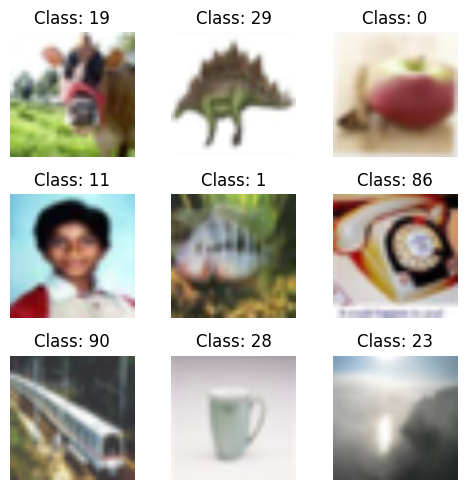

In [22]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5, 5))

for i in range(9):
    plt.subplot(3, 3, i+1)

    # 1.데이터셋에서 이미지와 라벨 추출
    image, label = trainset[i]

    # 2. Tensor를 Numpy로 변환하고 차원 변경 (C, H, W) -> (H, W, C)
    # plt.imshow는 마지막 차원이 채널인 것을 기대합니다.
    img_display = image.numpy().transpose((1, 2, 0))

    # 3. 정규화 해제 (0~1 사이 값으로 복원 - 선택 사항)
    # 만약 Normalize((0.5,), (0.5,))를 썼다면 이미지 시각화를 위해 복원이 필요할 수 있습니다.
    img_display = img_display * 0.5 + 0.5

    plt.imshow(img_display)
    plt.title(f"Class: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
import torch
import torch.nn as nn

# 하이퍼파라미터를 관리하기 편하게 클래스나 딕셔너리로 묶어줍니다.
class ViTConfig:
    batch_size = 256
    image_size = 224
    patch_size = 32 # 224/32 =7*749개 패치 생성
    num_patches = (image_size // patch_size) ** 2

    projection_dim = 64      # D (Embedding dimension)
                             # 모델이 한 단어 표현할때 64개 숫자사용하겠다(64차원)
    num_heads = 4            # 이미지의 각각 특징 4개

    # MLP (Feed Forward) 설정
    # Keras의 [projection_dim * 2, projection_dim]에 대응
    transformer_mlp_dim = projection_dim * 2

    transformer_layers = 12

    # 최종 분류 헤드 설정
    mlp_head_units = [2048, 1024] # 64->2048->1024
    num_classes = 100        # CIFAR-100 기준

    # 전처리된 49개의 패치 들어온다
    # norm+attention : 패치끼리 관계파악
    # norm+mlp : 파악된 특징을 128차원으로 해석
    # 이 과정을 12번 거친 후에 mlp head로 최종 결과물 보낸다 -> 분류해서 결론냄

In [24]:
# 데이터증강(data augmentation)

In [25]:
import torch
import torchvision.transforms as transforms
import numpy as np


image_size = 224  # ViT 입력 크기 표준


mean = [0.5071, 0.4867, 0.4408]
std = [0.2675, 0.2565, 0.2761]

# 데이터 증강 파이프라인 -> 학습할때 무작위로 적용시켜 동일한 이미지를 매번 다르게 보게 만들게 학습시킴
data_augmentation = transforms.Compose([

    transforms.Resize((image_size, image_size)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(degrees=7.2),

    transforms.RandomResizedCrop(size=(image_size, image_size), scale=(0.8, 1.0)),

    # PIL 이미지를 텐서로 변환 (0~255 값을 0~1로 스케일링)
    transforms.ToTensor(),

    transforms.Normalize(mean, std)
])

print(f"이미지 크기: {image_size}x{image_size}")

이미지 크기: 224x224


In [26]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, in_features, hidden_units, dropout_rate):
        super(MLP, self).__init__()
        layers = []


        for units in hidden_units:
            layers.append(nn.Linear(in_features, units))
            layers.append(nn.GELU())
            layers.append(nn.Dropout(dropout_rate))
            in_features = units # 다음 층의 입력은 현재 층의 출력 크기

        self.mlp = nn.Sequential(*layers) #[64->2048->1024]

    def forward(self, x):
        return self.mlp(x)

In [27]:
# ViT 이미지를 패치로 쪼갠다.
import torch.nn.functional as F

class Patches(nn.Module):
  def __init__(self, patch_size):
    super(Patches, self).__init__()
    self.patch_size=patch_size # 32라고 가정
    # 이미지를 격자(패치) 모양으로 쪼갠다.
    # 패치끼리 겹치지 않고 끊어서 자른다.
    self.unfold=nn.Unfold(kernel_size=patch_size, stride=patch_size)

  # patch_size 32라고 가정
  # 초기 자원(batch_size, 3,224,224) =>unfold 통과후의 차원 (batch_size, 3*32*32, 49) -> transpose(batch_size, 49, 3*32*32)
  # transpose -> Trabsfirner는 문장을 읽어서 [batch_size, 패치계수,패치 하나당 정보(차원)]
  def forward(self, images):
    patches=self.unfold(images)
    patches=patches.transpose(1,2)

    return patches

print("Patch클래스 정의함")


Patch클래스 정의함


Image 크기: 224 X 224
Patch 크기: 32 X 32


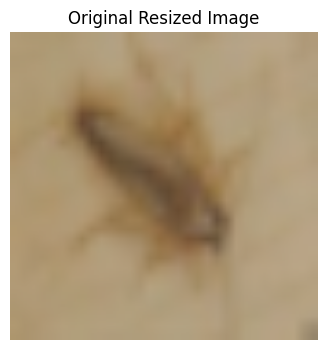

Image 크기: 224 X 224
Patch 크기: 32 X 32
이미지당 patch 수: 49
patch당 element 갯수: 3072
Shape of patch: torch.Size([1, 49, 3072])


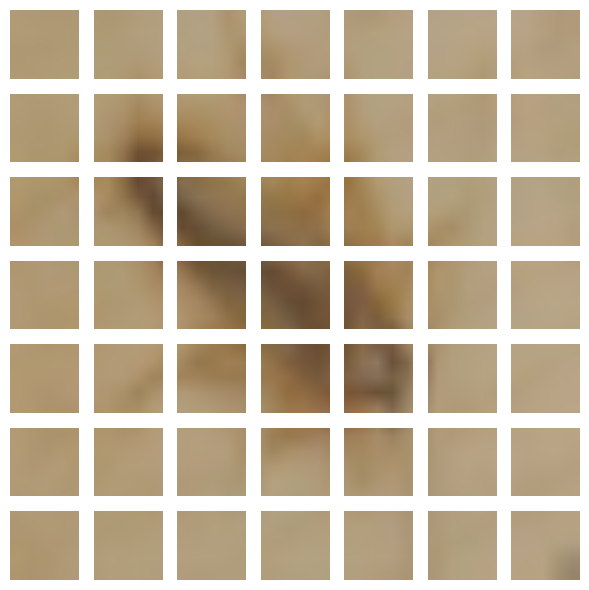

In [28]:
import matplotlib.pyplot as plt



image_size = 224
patch_size = 32


print(f'Image 크기: {image_size} X {image_size}')
print(f'Patch 크기: {patch_size} X {patch_size}')

# 학습 데이터셋(trainset)에서 랜덤하게 이미지 하나 선택
idx = np.random.choice(len(trainset))
image, label = trainset[idx]  # 이미 전처리(224x224)가 완료된 Tensor

# 원본 이미지 시각화를 위한 역전처리 (Normalize 해제)

# 이미지 텐서구조에 맞춰 모양 변형함 (3차원 구조로 변경) - C, H, W
mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(3, 1, 1)
std = torch.tensor([0.2675, 0.2565, 0.2761]).view(3, 1, 1)
img_display = image * std + mean

# permute(1, 2, 0) -> (H, W, C)로 복원
img_display = img_display.permute(1, 2, 0).numpy() # (H, W, C)로 변경
img_display = np.clip(img_display, 0, 1) # 범위를 0~1 사이로 제한

plt.figure(figsize=(4, 4))
plt.imshow(img_display)
plt.title("Original Resized Image")
plt.axis('off')
plt.show()

# Patches 클래스를 통과시켜 패치 생성
# Patches 클래스는 (Batch, C, H, W)를 기대하므로 unsqueeze(0)로 배치 차원 추가
image_batch = image.unsqueeze(0)
patches = Patches(patch_size=32)(image_batch) # 결과: (1, 49, 3072)


print(f'Image 크기: {image_size} X {image_size}')
print(f'Patch 크기: {patch_size} X {patch_size}')
print(f'이미지당 patch 수: {patches.shape[1]}')
print(f'patch당 element 갯수: {patches.shape[-1]}')
print(f'Shape of patch: {patches.shape}')

# 패치 시각화
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(6, 6))

for i, patch in enumerate(patches[0]):
    ax = plt.subplot(n, n, i+1)

    # (3072,) -> (3, 32, 32)로 되돌림
    patch_img = patch.reshape(3, patch_size, patch_size)

    # 시각화를 위해 (3, 32, 32) -> (32, 32, 3)으로 변경
    patch_img = patch_img.permute(1, 2, 0)

    # 역전처리 (색상 복원)
    patch_img = patch_img * std.squeeze() + mean.squeeze()
    patch_img = np.clip(patch_img.numpy(), 0, 1)

    plt.imshow(patch_img)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [29]:
class PatchEncoder(nn.Module):
    def __init__(self, num_patches, projection_dim):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches

        # Linear Projection: 1차원으로 펼쳐진 패치를 projection_dim으로 변환
        self.projection = nn.Linear(patch_size * patch_size * 3, projection_dim)

        # Position Embedding: 각 패치의 위치 정보를 학습 가능한 벡터로 저장
        self.position_embedding = nn.Embedding(
            num_embeddings=num_patches, # 49개의 위치 번호표
            embedding_dim=projection_dim # 위치 번호표에 대한 표현 차원 - 64차원의 벡터
        )

    def forward(self, patch):
        # patch shape: (batch_size, num_patches, patch_dims)

        # 0부터 num_patches-1까지의 정수 인덱스 생
        positions = torch.arange(0, self.num_patches, step=1, device=patch.device)

        # 패치 + 위치 임베딩 더하기
        # Vit가 보고 있는 패치 데이터 + 위치 정보
        # (batch, 49, 64) + (49, 64) -> 모든 배치에 동일 위치 정보가 더해지기 때문에 차원 달라도 에러 안남
        encoded = self.projection(patch) + self.position_embedding(positions)

        return encoded

In [33]:
from IPython.terminal.embed import embed
class ViT(nn.Module):
  def __init__(self, config):
    super().__init__()

    # 1. 입력 이미지 패치화(이미지 조각내고)
    self.patches=Patches(config.patch_size)

    # 2. 패치 인코더(선형+위치 임베딩) (64차원으로 압축하고, 위치 번호표 붙임)
    self.patch_encoder=PatchEncoder(config.num_patches, config.projection_dim)

    # 3. Transformer 리스트 생성 (12개 층 - 트랜스포머 블록 쌓을거임)
    # 일반 리스트 쓰면 파이토치가 모델 내부 가중치 찾지 못함 -> 반드시 ModuleList에 담는다.
    self.transformer_layers=nn.ModuleList([])

    # ViT-Base 모델은 12번 반복해서 쌓는다
    for _ in range(config.transformer_layers):
      self.transformer_layers.append(nn.ModuleDict({
          # 수많은 데이터가 층을 통과하면 너무 커지거나 작아지지 않게 표준화해줌
          "norm1":nn.LayerNorm(config.projection_dim, eps=1e-6),
          # 49개의 조각들이 서로 관련성 찾으면서 중요한 특징 추출
          "mha":nn.MultiheadAttention(
              embed_dim=config.projection_dim,
              num_heads=config.num_heads, # 각각 이미지를 다른 시각으로 분석
              dropout=0.1,
              batch_first=True
          ),
          "norm2":nn.LayerNorm(config.projection_dim, eps=1e-6),
          "mlp":MLP(in_features=config.projection_dim,
                    hidden_units=[config.transformer_mlp_dim, config.projection_dim],
                    dropout_rate=0.1)
      }))


    # 4. 최종 분류 헤드
    self.post_norm=nn.LayerNorm(config.projection_dim, eps=1e-6)
    # (49,64) 로 나누어져있던 데이터를 하나로 펼쳐서 3136개의 숫자로 만듬.
    self.flatten=nn.Flatten()
    self.dropout=nn.Dropout(0.5)

    # 특징 추출 mip(3136개 숫자 중 정답 맞히는데 필요한 핵심 특징 추출)
    self.mlp_head=MLP(
        in_features=config.num_patches*config.projection_dim,
        hidden_units=config.mlp_head_units,
        dropout_rate=0.5
    )

    # 최종 클래스 판별(100개 숫자 출력)
    self.classifier=nn.Linear(config.mlp_head_units[-1], config.num_classes)



  def forward(self, x):
        # x shape: (batch_size, 3, 224, 224)

        # 패치 분할 및 임베딩
        x = self.patches(x)
        x = self.patch_encoder(x) # (batch, 49, 64)

        # Transformer Blocks 반복 (Deep Learning)
        for layer in self.transformer_layers:
            # (1) Self-Attention + Residual Connection
            res = x
            x = layer["norm1"](x)
            x, _ = layer["mha"](x, x, x) # Query, Key, Value 모두 x
            x = x + res # Skip-connection

            # (2) MLP + Residual Connection
            res = x
            x = layer["norm2"](x)
            x = layer["mlp"](x)
            x = x + res # Skip-connection

        # 최종 출력 생성
        x = self.post_norm(x)
        x = self.flatten(x)
        x = self.dropout(x)

        x = self.mlp_head(x)
        logits = self.classifier(x)

        return logits

#  실행 및 결과 확인
config = ViTConfig()
model = ViT(config)

# 가상의 이미지 1장 생성 (배치 크기 1, 채널 3, 높이 224, 너비 224)
dummy_input = torch.randn(1, 3, 224, 224)
output = model(dummy_input)

In [34]:
import torch.optim as optim

# 하이퍼파라미터
num_epochs = 20
learning_rate = 0.001
# 가중치 커지지 않도록 패널티 줌(과적합 방지하기 위해)
weight_decay = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


model.to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

criterion = nn.CrossEntropyLoss()

In [35]:
def get_accuracy(outputs, labels, topk=(1, 5)):
  # 클래스 수가 많기 때문에 정답을 맞춘경우(topk=1), 상위 5개 예측안에 정답이 있을경우(topk=5)

    with torch.no_grad():
      # 모델 출력값에서 가장 높은 점수를 받은 상위maxk 값과 클래스 번호 반환함
        maxk = max(topk)
        batch_size = labels.size(0)

        _, pred = outputs.topk(maxk, 1, True, True) # (5, 가로, 높은순서, 정렬) (3,9.8, 4,9.4 ....)
        pred = pred.t() # 전치한 후 (상위 k값, batch_size)
        # 예측된 상위 5개 값이랑 실제 정답 비교해서 같으면 1, 아니면 0
        # (1, batch_size)
        correct = pred.eq(labels.view(1, -1).expand_as(pred)) # [0,1,0,0,0,......]

        res = []
        for k in topk:
          # 맞춘 개수를 다 더해서 100을 곱해 퍼센트로 변환
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res # [top1, top5]

In [36]:
from tqdm import tqdm

history = {'loss': [], 'acc': [], 'top5_acc': []}

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    running_top5 = 0.0


    pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for images, labels in pbar:
        # 데이터를 GPU로 이동
        images, labels = images.to(device), labels.to(device)

        # 기울기 초기화
        optimizer.zero_grad()

        # Forward (예측)
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward (기울기 계산) 및 Optimizer Step (가중치 업데이트)
        loss.backward()
        optimizer.step()


        acc1, acc5 = get_accuracy(outputs, labels)
        running_loss += loss.item()
        running_acc += acc1.item()
        running_top5 += acc5.item()

        pbar.set_postfix({'loss': loss.item(), 'acc': acc1.item()})


    epoch_loss = running_loss / len(trainloader)
    epoch_acc = running_acc / len(trainloader)
    epoch_top5 = running_top5 / len(trainloader)

    history['loss'].append(epoch_loss)
    history['acc'].append(epoch_acc)
    history['top5_acc'].append(epoch_top5)

    print(f"Summary -> Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%, Top-5: {epoch_top5:.2f}%")

Epoch 1/20: 100%|██████████| 1563/1563 [02:38<00:00,  9.83it/s, loss=4.24, acc=6.25]


Summary -> Loss: 4.0760, Acc: 8.41%, Top-5: 25.70%


Epoch 2/20: 100%|██████████| 1563/1563 [02:36<00:00,  9.98it/s, loss=3.23, acc=12.5]


Summary -> Loss: 3.7033, Acc: 13.28%, Top-5: 36.99%


Epoch 3/20: 100%|██████████| 1563/1563 [02:36<00:00,  9.96it/s, loss=3.48, acc=18.8]


...

Summary -> Loss: 3.3571, Acc: 19.05%, Top-5: 46.74%


Epoch 19/20: 100%|██████████| 1563/1563 [02:33<00:00, 10.19it/s, loss=3.7, acc=25]


Summary -> Loss: 3.3601, Acc: 19.00%, Top-5: 46.50%


Epoch 20/20: 100%|██████████| 1563/1563 [02:33<00:00, 10.20it/s, loss=4.18, acc=12.5]

Summary -> Loss: 3.3480, Acc: 19.38%, Top-5: 46.93%
